# Financial Ratio Comparison Tool for Listed Retail Companies
This peoject develops an interactive financial ratio comparison tool for listed retail companies. Using annual financial statement data from WRDS, the projcet compares selected firms across four key financial dimensions: profitability, liquidity, leverage, and efficiency. The final output is designed as a Streamlit-based interactive tool for accounting students and beginner users who want to compare company performance more clearly and efficiently.

## 1. Project Overiew

### 1.1 Background
Financial ratios are widely used in accounting and financial analysis to evaluate company performance. However, comparing companies using only one single ratio often leads to an incomplete understanding. A more balanced comparison should consider multiple dimensions, including profitability, liquidity, leverage, and efficiency. This project aims to address this issue by building a simple interactive tool that allows users to compare selected retail companies using a small set rey accounting ratios.

### 1.2 Project Objective
The objective of this project is to build an interactive financial ratio comparison tool for listed retail companies. The tool is intended to help users compare company performance over time and across firms using annual financial statement data. The project also demonstrates a complete Python workflow, including data extraction, cleaning, ratio calculation, visualization, and product-oriented output design.

## 2. Analytical Problem and Target Users

### 2.1 Analytical Problem
The main analytical problem addressed in this project is: How do selected retail companies differ in profitability, liquidity, leverage, and efficiency over time?
This question is important because financial performance cannot be fully understood through one metric alone. By comparing several accounting ratios together, users can obtain a more balanced view of how firms perform across multiple dimensions.

### 2.2 Target Users
The target users of this project are accounting students, finance beginners, and other users who want to compare company financial performance in a simple and interactive way. These users may not always be comfortable reading raw financial statements directly, so a ratio-based comparison tool can make the information easier to understand and interpret.

### 2.3 User Value
The value of this tool lies in its ability to transform raw company financial data into a more accessible comparison framework. Instead of manually calculating and interpreting several financial ratios, users can interactively select companies and review ratio trends, latest-year comparisons, and summary insights in one place.

## 3. Data Source and Company Selection

### 3.1 Data Source
The dataset used in this project is obtained from WRDS. WRDS was selected because it provides structured and reliable company financial statement data that are suitable for educational analysis. The project uses annual financial statement variables required for ratio calculation. The data access date should be clearly recorded for transparency and reproducibility.

### 3.2 Industry Selection
The retail industry was selected for this project because firms within the same industry are generally more comparable than firms across different industries. Retail companies often show meaningful differences in profitability, liquidity, leverage, and efficiency, which makes ratio analysis more informative and easier to interpret. In addition, ratio comparison within one industry helps reduce distortion caused by major business-model differences.

### 3.3 Candidate Companies
This project focuses on a selected pool of listed retail companies, including Walmart, Costco, Target, Kroger, Best Buy, and Home Depot. These firms were chosen because they are large listed companies with publicly available financial statement data and because they provide sufficient variation for financial ratio comparison while still remaining within the same broad industry.

### 3.4 Time Period
The analysis covers the period from 2020 to 2024. This time range is long enough to support trend analysis while remaining focused and manageable for a small interactive data product. It also allows users to observe whether the financial performance of selected firms is stable or changing over time.

## 4. Variables and Ratio Definitions

### 4.1 Raw Financial Variables
To calculate the selected accounting ratios, the project retains a limited set of raw financial variables from the annual financial statement data. These variables include revenue, net income, total assets, current assets, current liabilities, total liabilities, and shareholders' equity. Company name and fiscal year are also retained to support cross-company and time-series comparison.

### 4.2 Variable Description Table
The table below summarises the main variables used in this project.

| Variable | Meaning | Used for |
|---|---|---|
| company | Company name | Identification and comparison |
| fiscal_year | Fiscal year | Time-series analysis |
| revenue | Total sales/revenue | Net Profit Margin, Asset Turnover |
| net_income | Net income after tax | ROA, Net Profit Margin |
| total_assets | Total assets | ROA, Asset Turnover |
| current_assets | Current assets | Current Ratio |
| current_liabilities | Current liabilities | Current Ratio |
| total_liabilities | Total liabilities | Debt-to-Equity |
| shareholders_equity | Shareholders’ equity | Debt-to-Equity |

### 4.3 Selected Financial Ratios
This project uses five key accounting ratios to compare the selected companies. These ratios were selected because together they cover four important dimensions of company performance: profitability, liquidity, leverage, and efficiency. Using several ratios instead of one single ratio makes the comparison more balanced and informative.

### 4.4 Ratio Formula Table
The table below presents the financial ratios used in this project, together with their formulas and interpretations.

| Ratio | Formula | Interpretation |
|---|---|---|
| ROA | Net Income / Total Assets | Measures profitability relative to assets |
| Net Profit Margin | Net Income / Revenue | Measures profit generated from sales |
| Current Ratio | Current Assets / Current Liabilities | Measures short-term liquidity |
| Debt-to-Equity Ratio | Total Liabilities / Shareholders’ Equity | Measures leverage and financing risk |
| Asset Turnover | Revenue / Total Assets | Measures asset-use efficiency |

## 5. Data Extraction

### 5.1 Extracting Data from WRDS
The first technical step of the project is to extract the required annual financial statement data from WRDS. Only variables needed for ratio calculation and company identification are selected. This approach helps keep the workflow focused and avoids unnecessary complexity in the later stages of analysis.

In [1]:
import pandas as pd
import numpy as np
import wrds
import warnings

warnings.filterwarnings("ignore")

In [2]:
db = wrds.Connection()

Enter your WRDS username [joy]: jiayi24
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [3]:
# Define the selected retail companies for the analysis
company_list = [
    "WALMART INC",
    "COSTCO WHOLESALE CORP",
    "TARGET CORP",
    "KROGER CO",
    "BEST BUY CO INC",
    "HOME DEPOT INC"
]

# Define the fiscal year range for the sample
start_year = 2020
end_year = 2024

# Build a SQL query to extract annual financial statement data
# from WRDS Compustat Fundamentals Annual (compu.funda)
sql = f"""
select
    gvkey,
    conm,
    fyear,
    datadate,
    sale,
    ni,
    at,
    act,
    lct,
    lt,
    seq
from comp.funda
where indfmt = 'INDL'
  and datafmt = 'STD'
  and popsrc = 'D'
  and consol = 'C'
  and fyear between {start_year} and {end_year}
  and conm in ({",".join([f"'{c}'" for c in company_list])})
order by conm, fyear
"""

# Execute the SQL query and load the result into a pandas DataFrame
# Treat 'datadate' as a date column
raw_df = db.raw_sql(sql, date_cols=["datadate"])

# Rename Compustat variable names into more readable labels
# for easier understanding in later analysis
raw_df = raw_df.rename(columns={
    "conm": "company",
    "fyear": "fiscal_year",
    "sale": "revenue",
    "ni": "net_income",
    "at": "total_assets",
    "act": "current_assets",
    "lct": "current_liabilities",
    "lt": "total_liabilities",
    "seq": "shareholders_equity"
})

raw_df.head()

,gvkey,company,fiscal_year,datadate,revenue,net_income,total_assets,current_assets,current_liabilities,total_liabilities,shareholders_equity
0,002184,BEST BUY CO INC,2020,2021-01-31,47262.0,1798.0,19067.0,12540.0,10521.0,14480.0,4587.0
1,002184,BEST BUY CO INC,2021,2022-01-31,51761.0,2454.0,17504.0,10539.0,10674.0,14484.0,3020.0
2,002184,BEST BUY CO INC,2022,2023-01-31,46298.0,1419.0,15803.0,8802.0,8979.0,13008.0,2795.0
3,002184,BEST BUY CO INC,2023,2024-01-31,43452.0,1241.0,14967.0,7897.0,7909.0,11914.0,3053.0
4,002184,BEST BUY CO INC,2024,2025-01-31,41528.0,927.0,14782.0,8224.0,8016.0,11974.0,2808.0


### 5.2 Filtering Companies and Years
After the initial extraction, the dataset is filtered to keep only the selected retail companies and the target time period from 2020 to 2024. This step ensures that the analysis remains aligned with the project objective and that all observations are relevant to the planned comparison tool.

In [4]:
# Copy the extracted WRDS dataset into a working DataFrame
df = raw_df.copy()

# Keep only the selected retail companies and the target fiscal years
selected_companies = [
    "BEST BUY CO INC",
    "COSTCO WHOLESALE CORP",
    "HOME DEPOT INC",
    "KROGER CO",
    "TARGET CORP",
    "WALMART INC"
]

start_year = 2020
end_year = 2024

df = df[
    (df["company"].isin(selected_companies)) &
    (df["fiscal_year"] >= start_year) &
    (df["fiscal_year"] <= end_year)
].copy()

# Check the filtered sample by reviewing company names, years,
# observation counts, and overall dataset size
print("Companies in dataset:")
print(df["company"].unique())

print("\nFiscal years in dataset:")
print(df["fiscal_year"].unique())

print("\nNumber of observations by company:")
print(df["company"].value_counts().sort_index())

print("\nDataset shape:")
print(df.shape)

Companies in dataset:
<StringArray>
[      'BEST BUY CO INC', 'COSTCO WHOLESALE CORP',        'HOME DEPOT INC',
             'KROGER CO',           'TARGET CORP',           'WALMART INC']
Length: 6, dtype: string

Fiscal years in dataset:
<IntegerArray>
[2020, 2021, 2022, 2023, 2024]
Length: 5, dtype: Int64

Number of observations by company:
company
BEST BUY CO INC          5
COSTCO WHOLESALE CORP    5
HOME DEPOT INC           5
KROGER CO                5
TARGET CORP              5
WALMART INC              5
Name: count, dtype: Int64

Dataset shape:
(30, 11)


### 5.3 Initial Data Preview
Before cleaning and transformation, the extracted dataset is previewed to check its structure, variable types, and general completeness. This step is useful for identifying possible issues such as missing values, inconsistent company labels, or unexpected data formats.

In [5]:
# Display the size of the filtered dataset
# The output shows the number of rows and columns
print("Dataset shape:")
print(df.shape)

# Preview the first five rows of the dataset
# This helps check whether the extracted variables and sample look correct
print("\nFirst 5 rows:")
df.head()

Dataset shape:
(30, 11)

First 5 rows:


,gvkey,company,fiscal_year,datadate,revenue,net_income,total_assets,current_assets,current_liabilities,total_liabilities,shareholders_equity
0,002184,BEST BUY CO INC,2020,2021-01-31,47262.0,1798.0,19067.0,12540.0,10521.0,14480.0,4587.0
1,002184,BEST BUY CO INC,2021,2022-01-31,51761.0,2454.0,17504.0,10539.0,10674.0,14484.0,3020.0
2,002184,BEST BUY CO INC,2022,2023-01-31,46298.0,1419.0,15803.0,8802.0,8979.0,13008.0,2795.0
3,002184,BEST BUY CO INC,2023,2024-01-31,43452.0,1241.0,14967.0,7897.0,7909.0,11914.0,3053.0
4,002184,BEST BUY CO INC,2024,2025-01-31,41528.0,927.0,14782.0,8224.0,8016.0,11974.0,2808.0


In [6]:
# Check the overall structure of the dataset
# This shows column names, non-missing counts, and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   gvkey                30 non-null     string        
 1   company              30 non-null     string        
 2   fiscal_year          30 non-null     Int64         
 3   datadate             30 non-null     datetime64[ns]
 4   revenue              30 non-null     Float64       
 5   net_income           30 non-null     Float64       
 6   total_assets         30 non-null     Float64       
 7   current_assets       30 non-null     Float64       
 8   current_liabilities  30 non-null     Float64       
 9   total_liabilities    30 non-null     Float64       
 10  shareholders_equity  30 non-null     Float64       
dtypes: Float64(7), Int64(1), datetime64[ns](1), string(2)
memory usage: 2.9 KB


In [7]:
# Check the number of missing values in each column
# This helps identify whether any variables need cleaning before ratio calculation
print("Missing values by column:")
print(df.isnull().sum())

Missing values by column:
gvkey                  0
company                0
fiscal_year            0
datadate               0
revenue                0
net_income             0
total_assets           0
current_assets         0
current_liabilities    0
total_liabilities      0
shareholders_equity    0
dtype: int64


In [8]:
# Display summary statistics for the numerical variables
# This helps check the scale and distribution of the financial data
df.describe()

,fiscal_year,datadate,revenue,net_income,total_assets,current_assets,current_liabilities,total_liabilities,shareholders_equity
count,30.0,30,30.0,30.0,30.0,30.0,30.0,30.0,30.0
mean,2022.0,2023-01-05 16:48:00,212248.733333,7338.333333,85575.833333,30857.7,32356.5,62230.166667,22119.8
min,2020.0,2020-08-31 00:00:00,41528.0,927.0,14782.0,7897.0,7909.0,11914.0,-1696.0
25%,2021.0,2022-01-31 00:00:00,106777.5,2486.75,49843.5,12739.5,16124.25,38956.0,3621.0
50%,2022.0,2023-01-31 00:00:00,149148.5,4687.5,56662.5,24846.5,21881.0,42603.0,11423.5
75%,2023.0,2024-01-31 00:00:00,219197.75,13349.0,75302.75,32639.75,31358.75,74555.25,20052.5
max,2024.0,2025-01-31 00:00:00,678338.0,19436.0,260823.0,90067.0,96584.0,164965.0,91013.0
std,1.43839,NaN,190649.155096,5881.939988,77686.903058,24280.799541,28211.04423,48528.255886,28617.993295


## 6. Data Cleaning and Preparation

### 6.1 Selecting Relevant Columns
To simplify the workflow, only the variables required for ratio calculation and comparison are retained. Removing unnecessary columns improves readability and makes the later stages of processing more efficient.

In [9]:
# Keep only the variables required for later ratio calculation and comparison
# This makes the dataset more focused and easier to use in the cleaning stage
df = df[[
    "gvkey",
    "company",
    "fiscal_year",
    "datadate",
    "revenue",
    "net_income",
    "total_assets",
    "current_assets",
    "current_liabilities",
    "total_liabilities",
    "shareholders_equity"
]].copy()

# Preview the first five rows after selecting the relevant columns
df.head()

,gvkey,company,fiscal_year,datadate,revenue,net_income,total_assets,current_assets,current_liabilities,total_liabilities,shareholders_equity
0,002184,BEST BUY CO INC,2020,2021-01-31,47262.0,1798.0,19067.0,12540.0,10521.0,14480.0,4587.0
1,002184,BEST BUY CO INC,2021,2022-01-31,51761.0,2454.0,17504.0,10539.0,10674.0,14484.0,3020.0
2,002184,BEST BUY CO INC,2022,2023-01-31,46298.0,1419.0,15803.0,8802.0,8979.0,13008.0,2795.0
3,002184,BEST BUY CO INC,2023,2024-01-31,43452.0,1241.0,14967.0,7897.0,7909.0,11914.0,3053.0
4,002184,BEST BUY CO INC,2024,2025-01-31,41528.0,927.0,14782.0,8224.0,8016.0,11974.0,2808.0


### 6.2 Handling Missing Values
Missing values are checked to ensure that ratio calculations are based on valid observations. If a required variable is missing for a given company-year observation, the corresponding ratio may not be calculated. This step helps avoid misleading results and improves the reliability of the analysis.

In [10]:
# Check the number of missing values in each column before cleaning
# This helps identify whether any key financial variables are incomplete
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
gvkey                  0
company                0
fiscal_year            0
datadate               0
revenue                0
net_income             0
total_assets           0
current_assets         0
current_liabilities    0
total_liabilities      0
shareholders_equity    0
dtype: int64


In [11]:
# Define the key financial variables required for later ratio calculation
required_cols = [
    "revenue",
    "net_income",
    "total_assets",
    "current_assets",
    "current_liabilities",
    "total_liabilities",
    "shareholders_equity"
]

# Remove observations with missing values in the required variables
# This ensures that the later ratio calculations are based on complete data
df = df.dropna(subset=required_cols).copy()

# Check missing values again after cleaning
print("Missing values after cleaning:")
print(df.isnull().sum())

# Check the size of the dataset after removing incomplete observations
print("\nDataset shape after dropping missing values:")
print(df.shape)

Missing values after cleaning:
gvkey                  0
company                0
fiscal_year            0
datadate               0
revenue                0
net_income             0
total_assets           0
current_assets         0
current_liabilities    0
total_liabilities      0
shareholders_equity    0
dtype: int64

Dataset shape after dropping missing values:
(30, 11)


### 6.3 Validity Checks for Ratio Calculation
Before calculating the financial ratios, denominator values are checked to avoid division by zero or invalid calculations. For example, total assets, current liabilities, and shareholders’ equity must be valid and non-zero when used in ratio formulas. This step is necessary to ensure technical correctness.

In [11]:
# Check whether any denominator variables contain zero values
# This is important because later ratio calculations involve division
print("Rows with zero revenue:", (df["revenue"] == 0).sum())
print("Rows with zero total_assets:", (df["total_assets"] == 0).sum())
print("Rows with zero current_liabilities:", (df["current_liabilities"] == 0).sum())
print("Rows with zero shareholders_equity:", (df["shareholders_equity"] == 0).sum())

Rows with zero revenue: 0
Rows with zero total_assets: 0
Rows with zero current_liabilities: 0
Rows with zero shareholders_equity: 0


In [12]:
# Remove observations with zero values in key denominator variables
# This ensures that later ratio calculations do not involve division by zero
df = df[
    (df["revenue"] != 0) &
    (df["total_assets"] != 0) &
    (df["current_liabilities"] != 0) &
    (df["shareholders_equity"] != 0)
].copy()

# Check the dataset size after denominator validity checks
print("Dataset shape after denominator checks:")
print(df.shape)

Dataset shape after denominator checks:
(30, 11)


### 6.4 Preparing the Final Cleaned Dataset
After filtering and cleaning, the dataset is transformed into a final company-year panel that is ready for ratio calculation. At this stage, the dataset includes only the selected companies, years, and valid financial statement variables needed for the analysis.

In [14]:
# Sort the cleaned dataset by company and fiscal year
# Reset the index to create a clean and orderly DataFrame
df = df.sort_values(["company", "fiscal_year"]).reset_index(drop=True)

# Preview the first five rows after sorting
df.head()

,gvkey,company,fiscal_year,datadate,revenue,net_income,total_assets,current_assets,current_liabilities,total_liabilities,shareholders_equity
0,002184,BEST BUY CO INC,2020,2021-01-31,47262.0,1798.0,19067.0,12540.0,10521.0,14480.0,4587.0
1,002184,BEST BUY CO INC,2021,2022-01-31,51761.0,2454.0,17504.0,10539.0,10674.0,14484.0,3020.0
2,002184,BEST BUY CO INC,2022,2023-01-31,46298.0,1419.0,15803.0,8802.0,8979.0,13008.0,2795.0
3,002184,BEST BUY CO INC,2023,2024-01-31,43452.0,1241.0,14967.0,7897.0,7909.0,11914.0,3053.0
4,002184,BEST BUY CO INC,2024,2025-01-31,41528.0,927.0,14782.0,8224.0,8016.0,11974.0,2808.0


## 7. Ratio Calculation

### 7.1 Calculating Profitability Ratios
The first group of ratios measures profitability. ROA is used to evaluate how effectively a company uses its assets to generate profit, while net profit margin shows how much net profit is earned from each unit of revenue. These two ratios together provide a broader view of profit performance.

In [21]:
df["roa"] = df["net_income"] / df["total_assets"]
df["net_profit_margin"] = df["net_income"] / df["revenue"]

df[["company", "fiscal_year", "roa", "net_profit_margin"]].head()

,company,fiscal_year,roa,net_profit_margin
0,BEST BUY CO INC,2020,0.094299,0.038043
1,BEST BUY CO INC,2021,0.140197,0.04741
2,BEST BUY CO INC,2022,0.089793,0.030649
3,BEST BUY CO INC,2023,0.082916,0.02856
4,BEST BUY CO INC,2024,0.062711,0.022322


### 7.2 Calculating Liquidity Ratio
The current ratio is used to measure short-term liquidity. It indicates whether a company has sufficient current assets to cover its current liabilities. This ratio is useful for comparing short-term financial flexibility across firms.

In [22]:
df["current_ratio"] = df["current_assets"] / df["current_liabilities"]

df[["company", "fiscal_year", "current_ratio"]].head()

,company,fiscal_year,current_ratio
0,BEST BUY CO INC,2020,1.191902
1,BEST BUY CO INC,2021,0.987352
2,BEST BUY CO INC,2022,0.980287
3,BEST BUY CO INC,2023,0.998483
4,BEST BUY CO INC,2024,1.025948


### 7.3 Calculating Leverage Ratio
The debt-to-equity ratio is used to measure leverage. It reflects the extent to which a company relies on liabilities relative to shareholders’ equity. A higher value generally suggests a greater dependence on debt financing and potentially higher financial risk.

In [23]:
df["debt_to_equity"] = df["total_liabilities"] / df["shareholders_equity"]

df[["company", "fiscal_year", "debt_to_equity"]].head()

,company,fiscal_year,debt_to_equity
0,BEST BUY CO INC,2020,3.156747
1,BEST BUY CO INC,2021,4.796026
2,BEST BUY CO INC,2022,4.654025
3,BEST BUY CO INC,2023,3.902391
4,BEST BUY CO INC,2024,4.264245


### 7.4 Calculating Efficiency Ratio
Asset turnover is used to evaluate how efficiently a company uses its assets to generate revenue. This ratio is especially meaningful in the retail industry, where sales generation and asset utilization are important aspects of business performance.

In [24]:
df["asset_turnover"] = df["revenue"] / df["total_assets"]

df[["company", "fiscal_year", "asset_turnover"]].head()

,company,fiscal_year,asset_turnover
0,BEST BUY CO INC,2020,2.478733
1,BEST BUY CO INC,2021,2.957096
2,BEST BUY CO INC,2022,2.929697
3,BEST BUY CO INC,2023,2.903187
4,BEST BUY CO INC,2024,2.809363


### 7.5 Final Ratio Dataset
After all five ratios are calculated, the resulting dataset contains both the raw financial variables and the newly created ratio variables. This ratio-level dataset forms the basis for the visual analysis and for the final Streamlit tool.


In [25]:
# Create a final ratio-level dataset for later analysis and visualization
df_ratio = df.copy()

# Preview the first five rows of the final ratio dataset
df_ratio.head()

,gvkey,company,fiscal_year,datadate,revenue,net_income,total_assets,current_assets,current_liabilities,total_liabilities,shareholders_equity,roa,net_profit_margin,current_ratio,debt_to_equity,asset_turnover
0,002184,BEST BUY CO INC,2020,2021-01-31,47262.0,1798.0,19067.0,12540.0,10521.0,14480.0,4587.0,0.094299,0.038043,1.191902,3.156747,2.478733
1,002184,BEST BUY CO INC,2021,2022-01-31,51761.0,2454.0,17504.0,10539.0,10674.0,14484.0,3020.0,0.140197,0.04741,0.987352,4.796026,2.957096
2,002184,BEST BUY CO INC,2022,2023-01-31,46298.0,1419.0,15803.0,8802.0,8979.0,13008.0,2795.0,0.089793,0.030649,0.980287,4.654025,2.929697
3,002184,BEST BUY CO INC,2023,2024-01-31,43452.0,1241.0,14967.0,7897.0,7909.0,11914.0,3053.0,0.082916,0.02856,0.998483,3.902391,2.903187
4,002184,BEST BUY CO INC,2024,2025-01-31,41528.0,927.0,14782.0,8224.0,8016.0,11974.0,2808.0,0.062711,0.022322,1.025948,4.264245,2.809363


In [27]:
# Define the ratio columns in the final dataset
ratio_cols = ["roa", "net_profit_margin", "current_ratio", "debt_to_equity", "asset_turnover"]

# Round the ratio values to four decimal places for cleaner presentation
df_ratio[ratio_cols] = df_ratio[ratio_cols].round(4)

# Preview the first five rows after formatting the ratio columns
df_ratio.head()

,gvkey,company,fiscal_year,datadate,revenue,net_income,total_assets,current_assets,current_liabilities,total_liabilities,shareholders_equity,roa,net_profit_margin,current_ratio,debt_to_equity,asset_turnover
0,002184,BEST BUY CO INC,2020,2021-01-31,47262.0,1798.0,19067.0,12540.0,10521.0,14480.0,4587.0,0.0943,0.038,1.1919,3.1567,2.4787
1,002184,BEST BUY CO INC,2021,2022-01-31,51761.0,2454.0,17504.0,10539.0,10674.0,14484.0,3020.0,0.1402,0.0474,0.9874,4.796,2.9571
2,002184,BEST BUY CO INC,2022,2023-01-31,46298.0,1419.0,15803.0,8802.0,8979.0,13008.0,2795.0,0.0898,0.0306,0.9803,4.654,2.9297
3,002184,BEST BUY CO INC,2023,2024-01-31,43452.0,1241.0,14967.0,7897.0,7909.0,11914.0,3053.0,0.0829,0.0286,0.9985,3.9024,2.9032
4,002184,BEST BUY CO INC,2024,2025-01-31,41528.0,927.0,14782.0,8224.0,8016.0,11974.0,2808.0,0.0627,0.0223,1.0259,4.2642,2.8094


## 8. Exploratory Data Analysis

### 8.1 Dataset Overiew
The cleaned dataset is first examined at a general level to confirm the number of firms, years, and observations included in the analysis. This step helps ensure that the final dataset matches the intended project scope.

In [28]:
# Check how many companies are included in the final ratio dataset
print("Number of companies:", df_ratio["company"].nunique())

# Display the company names included in the dataset
print("Companies:", df_ratio["company"].unique())

# Check the fiscal year range covered by the dataset
print("\nYear range:", df_ratio["fiscal_year"].min(), "to", df_ratio["fiscal_year"].max())

# Display the overall size of the final ratio dataset
print("Dataset shape:", df_ratio.shape)

Number of companies: 6
Companies: <StringArray>
[      'BEST BUY CO INC', 'COSTCO WHOLESALE CORP',        'HOME DEPOT INC',
             'KROGER CO',           'TARGET CORP',           'WALMART INC']
Length: 6, dtype: string

Year range: 2020 to 2024
Dataset shape: (30, 16)


### 8.2 Descriptive Statistics
Descriptive statistics are used to summarise the main features of the ratio dataset. These summaries provide an initial understanding of the scale, distribution, and variation of the selected financial ratios before detailed visual comparison is conducted.

In [29]:
df_ratio[["roa", "net_profit_margin", "current_ratio", "debt_to_equity", "asset_turnover"]].describe()

,roa,net_profit_margin,current_ratio,debt_to_equity,asset_turnover
count,30.0,30.0,30.0,30.0,30.0
mean,0.094383,0.040597,0.98978,6.261313,2.562477
std,0.053804,0.029815,0.159603,17.710334,0.558896
min,0.0337,0.012,0.735,-43.3797,1.6595
25%,0.054075,0.024,0.9086,2.04785,2.049175
50%,0.07885,0.0273,0.98385,3.1759,2.5796
75%,0.1027,0.04465,1.030025,4.24705,2.95025
max,0.2286,0.1087,1.4051,72.3046,3.6438


### 8.3 Preliminary Observations
The exploratory stage also helps identify broad patterns in the data. For example, some companies may appear to have stronger profitability, while others may show higher liquidity or greater leverage. These preliminary observations provide a useful starting point for later interpretation.

In [30]:
# Group the final ratio dataset by company
# Calculate the average value of each selected ratio for each firm
company_summary = df_ratio.groupby("company")[[
    "roa",
    "net_profit_margin",
    "current_ratio",
    "debt_to_equity",
    "asset_turnover"
]].mean().round(4)

# Display the company-level average ratio summary
company_summary

,roa,net_profit_margin,current_ratio,debt_to_equity,asset_turnover
company,,,,,
BEST BUY CO INC,0.094,0.0334,1.0368,4.1547,2.8156
COSTCO WHOLESALE CORP,0.0889,0.0261,1.038,2.0357,3.4
HOME DEPOT INC,0.1973,0.1014,1.221,22.1472,1.9376
KROGER CO,0.0451,0.0158,0.8118,4.185,2.8573
TARGET CORP,0.0824,0.0429,0.9561,3.1106,1.9253
WALMART INC,0.0587,0.024,0.875,1.9348,2.4389


## 9. Visual Comparison of Financial Ratios

### 9.1 Ratio Trends Over Time
Trend charts are used to compare how each selected ratio changes over time for the chosen companies. This time-series perspective makes it easier to identify stable performers, changing patterns, or differences in financial structure across firms.

In [31]:
import matplotlib.pyplot as plt

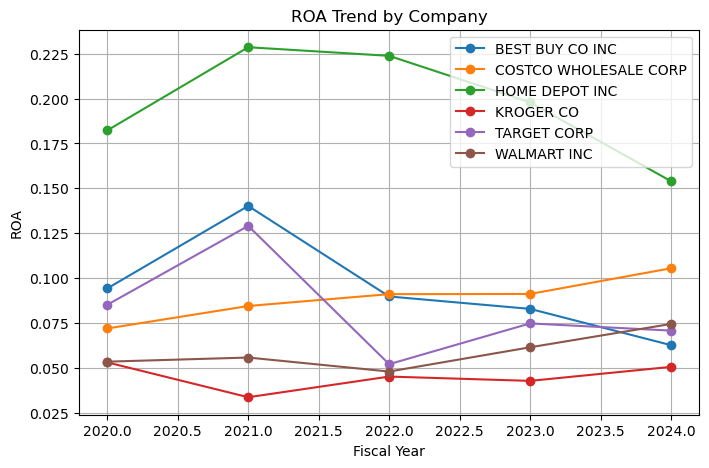

In [32]:
plt.figure(figsize=(8, 5))
for company in df_ratio["company"].unique():
    temp = df_ratio[df_ratio["company"] == company]
    plt.plot(temp["fiscal_year"], temp["roa"], marker="o", label=company)

plt.title("ROA Trend by Company")
plt.xlabel("Fiscal Year")
plt.ylabel("ROA")
plt.legend()
plt.grid(True)
plt.show()

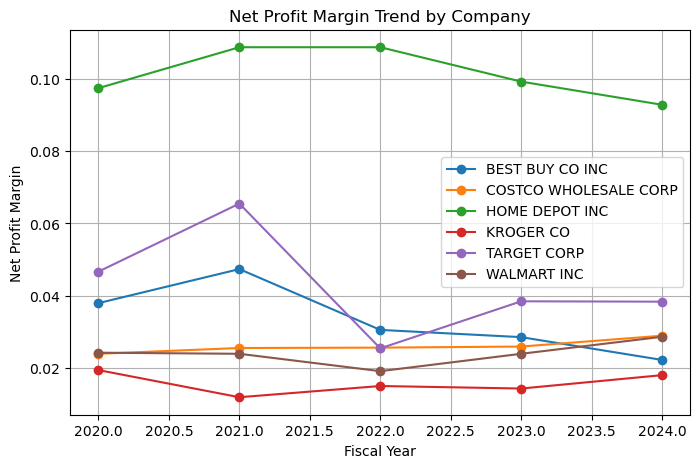

In [33]:
plt.figure(figsize=(8, 5))
for company in df_ratio["company"].unique():
    temp = df_ratio[df_ratio["company"] == company]
    plt.plot(temp["fiscal_year"], temp["net_profit_margin"], marker="o", label=company)

plt.title("Net Profit Margin Trend by Company")
plt.xlabel("Fiscal Year")
plt.ylabel("Net Profit Margin")
plt.legend()
plt.grid(True)
plt.show()

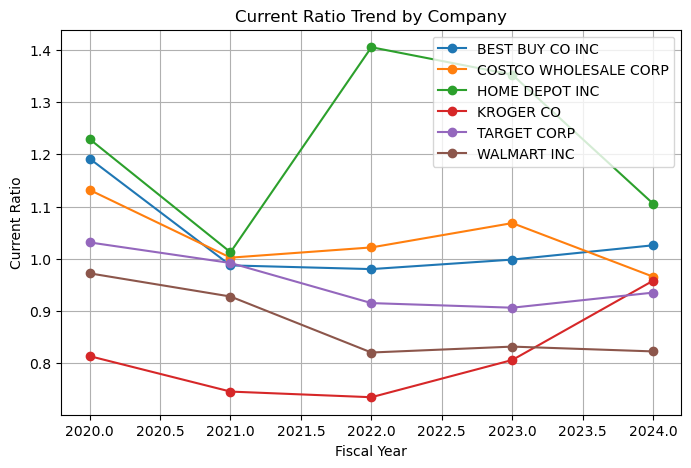

In [34]:
plt.figure(figsize=(8, 5))
for company in df_ratio["company"].unique():
    temp = df_ratio[df_ratio["company"] == company]
    plt.plot(temp["fiscal_year"], temp["current_ratio"], marker="o", label=company)

plt.title("Current Ratio Trend by Company")
plt.xlabel("Fiscal Year")
plt.ylabel("Current Ratio")
plt.legend()
plt.grid(True)
plt.show()

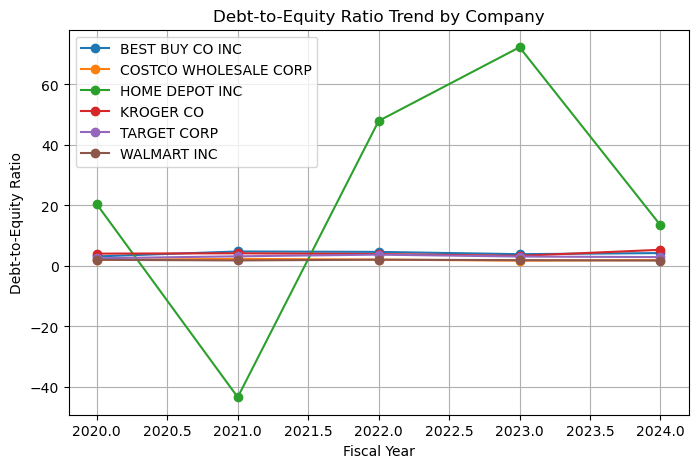

In [35]:
plt.figure(figsize=(8, 5))
for company in df_ratio["company"].unique():
    temp = df_ratio[df_ratio["company"] == company]
    plt.plot(temp["fiscal_year"], temp["debt_to_equity"], marker="o", label=company)

plt.title("Debt-to-Equity Ratio Trend by Company")
plt.xlabel("Fiscal Year")
plt.ylabel("Debt-to-Equity Ratio")
plt.legend()
plt.grid(True)
plt.show()

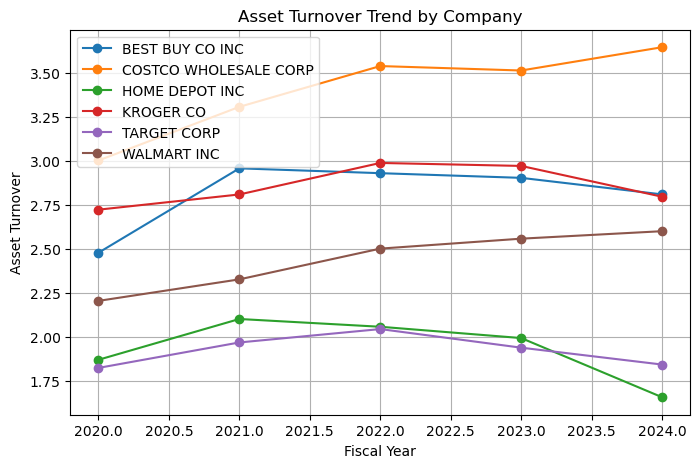

In [36]:
plt.figure(figsize=(8, 5))
for company in df_ratio["company"].unique():
    temp = df_ratio[df_ratio["company"] == company]
    plt.plot(temp["fiscal_year"], temp["asset_turnover"], marker="o", label=company)

plt.title("Asset Turnover Trend by Company")
plt.xlabel("Fiscal Year")
plt.ylabel("Asset Turnover")
plt.legend()
plt.grid(True)
plt.show()

### 9.2 Latest-Year Comparison
In addition to trend analysis, the project also compares the selected companies in the most recent year available within the chosen period. This provides a simpler snapshot of comparative performance and allows users to quickly identify which firms appear stronger or weaker in each ratio.

In [38]:
# Identify the most recent fiscal year in the final ratio dataset
latest_year = df_ratio["fiscal_year"].max()

# Keep only the observations from the latest year
latest_df = df_ratio[df_ratio["fiscal_year"] == latest_year].copy()

# Display the latest year and preview the filtered dataset
print("Latest year:", latest_year)
latest_df.head()

Latest year: 2024


,gvkey,company,fiscal_year,datadate,revenue,net_income,total_assets,current_assets,current_liabilities,total_liabilities,shareholders_equity,roa,net_profit_margin,current_ratio,debt_to_equity,asset_turnover
4,002184,BEST BUY CO INC,2024,2025-01-31,41528.0,927.0,14782.0,8224.0,8016.0,11974.0,2808.0,0.0627,0.0223,1.0259,4.2642,2.8094
9,029028,COSTCO WHOLESALE CORP,2024,2024-08-31,254453.0,7367.0,69831.0,34246.0,35464.0,46209.0,23622.0,0.1055,0.029,0.9657,1.9562,3.6438
14,005680,HOME DEPOT INC,2024,2025-01-31,159514.0,14806.0,96119.0,31683.0,28661.0,89479.0,6640.0,0.154,0.0928,1.1054,13.4758,1.6595
19,006502,KROGER CO,2024,2025-01-31,147123.0,2665.0,52616.0,15273.0,15940.0,44335.0,8285.0,0.0506,0.0181,0.9582,5.3512,2.7962
24,003813,TARGET CORP,2024,2025-01-31,106566.0,4091.0,57769.0,19454.0,20799.0,43103.0,14666.0,0.0708,0.0384,0.9353,2.939,1.8447


In [39]:
latest_comparison = latest_df[[
    "company",
    "roa",
    "net_profit_margin",
    "current_ratio",
    "debt_to_equity",
    "asset_turnover"
]].round(4)

latest_comparison

,company,roa,net_profit_margin,current_ratio,debt_to_equity,asset_turnover
4,BEST BUY CO INC,0.0627,0.0223,1.0259,4.2642,2.8094
9,COSTCO WHOLESALE CORP,0.1055,0.029,0.9657,1.9562,3.6438
14,HOME DEPOT INC,0.154,0.0928,1.1054,13.4758,1.6595
19,KROGER CO,0.0506,0.0181,0.9582,5.3512,2.7962
24,TARGET CORP,0.0708,0.0384,0.9353,2.939,1.8447
29,WALMART INC,0.0745,0.0287,0.8227,1.7924,2.6008


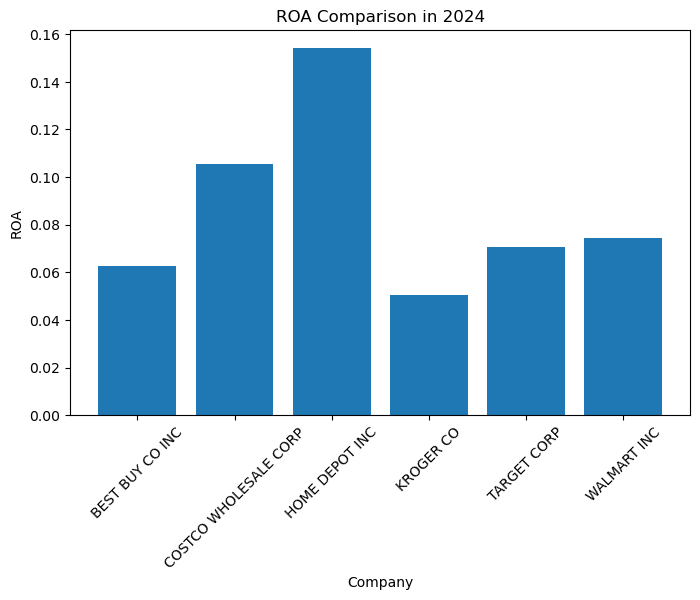

In [40]:
plt.figure(figsize=(8, 5))
plt.bar(latest_df["company"], latest_df["roa"])
plt.title(f"ROA Comparison in {latest_year}")
plt.xlabel("Company")
plt.ylabel("ROA")
plt.xticks(rotation=45)
plt.show()

### 9.3 Why Visualization Matters
Visualization is an important part of this project because raw financial numbers can be difficult to interpret directly. By converting the ratio dataset into charts and comparison tables, the project makes the analytical results more accessible and easier for users to understand.

## 10. Key Findings and Interpretation

In [41]:
# Rank the companies in the latest fiscal year across the five selected ratios
# The ranking is calculated in descending order, so larger values receive stronger ranks
# Note: debt-to-equity should be interpreted carefully, since a higher value does not necessarily mean better performance
latest_df.set_index("company")[[
    "roa",
    "net_profit_margin",
    "current_ratio",
    "debt_to_equity",
    "asset_turnover"
]].rank(ascending=False).round(2)

,roa,net_profit_margin,current_ratio,debt_to_equity,asset_turnover
company,,,,,
BEST BUY CO INC,5.0,5.0,2.0,3.0,2.0
COSTCO WHOLESALE CORP,2.0,3.0,3.0,5.0,1.0
HOME DEPOT INC,1.0,1.0,1.0,1.0,6.0
KROGER CO,6.0,6.0,4.0,2.0,3.0
TARGET CORP,4.0,2.0,5.0,4.0,5.0
WALMART INC,3.0,4.0,6.0,6.0,4.0


In [42]:
# Group the final ratio dataset by company
# Calculate the average value of each selected ratio over the full sample period
average_ratios = df_ratio.groupby("company")[[
    "roa",
    "net_profit_margin",
    "current_ratio",
    "debt_to_equity",
    "asset_turnover"
]].mean().round(4)

# Display the multi-year average ratio summary for each company
average_ratios

,roa,net_profit_margin,current_ratio,debt_to_equity,asset_turnover
company,,,,,
BEST BUY CO INC,0.094,0.0334,1.0368,4.1547,2.8156
COSTCO WHOLESALE CORP,0.0889,0.0261,1.038,2.0357,3.4
HOME DEPOT INC,0.1973,0.1014,1.221,22.1472,1.9376
KROGER CO,0.0451,0.0158,0.8118,4.185,2.8573
TARGET CORP,0.0824,0.0429,0.9561,3.1106,1.9253
WALMART INC,0.0587,0.024,0.875,1.9348,2.4389


### 10.1 Profitability Findings
The profitability comparison shows clear differences across the selected retail companies. Based on both the average ratios over 2020–2024 and the latest-year results, Home Depot appears to be the strongest profitability performer in the sample. It recorded the highest average ROA (0.1973) and net profit margin (0.1014), and it also remained the leading firm in 2024, with a ROA of 0.1540 and a net profit margin of 0.0928. Although both indicators declined slightly in the most recent year compared with earlier peaks, Home Depot still outperformed the other selected firms by a clear margin.

A second group of firms shows moderate but lower profitability. Costco maintained a relatively steady upward trend in ROA and reached 0.1055 in 2024, making it one of the stronger recent performers. Target also showed relatively strong net profit margin on average (0.0429), although its profitability was more volatile, especially due to a sharp increase in 2021 followed by a noticeable decline in 2022. Best Buy performed relatively well at the beginning of the period, but both ROA and net profit margin weakened after 2021.

At the lower end, Walmart and Kroger showed more modest profitability. Walmart improved gradually in the later years, especially in ROA, while Kroger remained the weakest company in average profitability, with an average ROA of 0.0451 and an average net profit margin of 0.0158. Overall, the profitability results suggest that Home Depot stands out clearly, while the other firms remain closer to a middle or lower profitability range.

### 10.2 Liquidity Findings
The liquidity comparison is based on the current ratio, which reflects the extent to which current assets can cover current liabilities. Among the selected firms, Home Depot showed the strongest liquidity position on average, with an average current ratio of 1.2210, and it also recorded the highest value in 2024 (1.1054). However, its liquidity pattern was not fully stable across the period, as the ratio increased sharply in 2022 before declining again in later years.

Best Buy and Costco showed relatively balanced liquidity positions. Both firms remained around or slightly above 1 in most years, suggesting a more stable short-term financial position. In 2024, Best Buy reported a current ratio of 1.0259, while Costco reported 0.9657, which is slightly below 1 but still close to a balanced short-term level.

By contrast, Target, Kroger, and Walmart showed weaker liquidity overall. Their average current ratios remained below 1, particularly for Kroger (0.8118) and Walmart (0.8750). This suggests that these firms operated with tighter short-term liquidity during much of the selected period. Even so, Kroger’s current ratio improved by 2024, reaching 0.9582. Overall, the liquidity results suggest that the selected firms differ meaningfully in working-capital structure and short-term financial flexibility.

### 10.3 Leverage Findings
The leverage comparison is based on the debt-to-equity ratio, and the results indicate substantial differences across the selected companies. Home Depot recorded by far the highest average debt-to-equity ratio (22.1472), and its ratio also fluctuated sharply across the period. The trend chart shows unusually large variation, including a negative value in one year and very high positive values in later years. This means that Home Depot’s debt-to-equity ratio should be interpreted with caution, since extreme values may reflect unusually low or negative shareholders’ equity rather than a simple increase in debt.

Among the remaining firms, Walmart and Costco showed comparatively lower leverage in the latest year. In 2024, Walmart recorded the lowest debt-to-equity ratio (1.7924), followed by Costco (1.9562). This suggests that their capital structures were relatively less debt-heavy than those of the other selected firms in that year. Target, Best Buy, and Kroger all reported higher leverage, with Kroger showing the highest 2024 value among this group (5.3512).

Overall, the leverage results suggest that financing structures differ significantly across the selected retail companies. However, this ratio should not be interpreted mechanically, especially when equity values are unusually low or unstable. For this reason, leverage should be considered together with profitability, liquidity, and efficiency rather than treated as a stand-alone indicator of performance.

### 10.4 Efficiency Findings
The efficiency comparison is based on asset turnover, which is particularly relevant in the retail industry because it measures how effectively a company uses its assets to generate sales. In this dimension, Costco is the strongest performer. It recorded the highest average asset turnover (3.4000) over 2020–2024 and also the highest 2024 value (3.6438). Its trend remained consistently strong and generally improved over time, suggesting highly efficient asset use.

A second group of relatively efficient firms includes Kroger and Best Buy. Both maintained asset turnover values above 2.7 for most of the selected period, indicating relatively strong operating efficiency compared with the rest of the sample. Walmart also performed steadily in this dimension, with asset turnover gradually improving over time and reaching 2.6008 in 2024.

By contrast, Home Depot and Target recorded the lowest asset turnover values on average, at 1.9376 and 1.9253 respectively. Home Depot is especially interesting because it combines the strongest profitability with relatively low asset turnover. This suggests that its overall strength is supported more by strong profit generation than by high sales per unit of assets. Overall, the efficiency results show that firms can perform quite differently depending on which financial dimension is being examined.

### 10.5 Overall Interpretation
Overall, the results show that no single company is the strongest in every financial dimension. Home Depot stands out clearly in profitability and also shows relatively strong liquidity, but its leverage ratio is unusually volatile and its asset turnover is comparatively low. Costco appears to be the most balanced company in the sample, combining strong efficiency with relatively solid profitability and moderate leverage. Best Buy and Target show mixed performance, with some stronger areas but also noticeable volatility. Walmart appears more stable than outstanding, while Kroger generally performs weakly in profitability and liquidity but remains relatively stronger in efficiency.

These findings support the main argument of the project: company performance should not be evaluated using only one financial ratio. A firm may appear strong in profitability but weaker in efficiency or leverage, while another may perform well operationally without having the highest margins. Therefore, using multiple ratios together provides a more balanced and informative comparison of financial performance across listed retail companies.

## 11. Preparing the Data Product

### 11.1 Exporting the Processed Dataset
After the analysis is completed in Python, the cleaned ratio dataset is exported for use in the Streamlit application. Exporting a processed dataset allows the final tool to load data more efficiently without repeating the full extraction and cleaning process.

In [43]:
df_ratio.to_csv("cleaned_ratios.csv", index=False)
print("cleaned_ratios.csv has been saved successfully.")

cleaned_ratios.csv has been saved successfully.


### 11.2 Product Design Logic
The Streamlit tool is designed to allow users to select up to three companies from the candidate pool and compare them across selected years and ratios. The main product components include ratio trend charts, latest-year comparison, summary insights, and a ratio data table. This structure is intended to make the analytical output more accessible and interactive.

### 11.3 Why Streamlit Was Used
Streamlit was selected because it provides a simple and effective way to transform Python analysis into an interactive user-facing product. It is suitable for a small data product project because it supports user input, chart display, and lightweight deployment without requiring advanced web development skills.

## 12. Limitations

### 12.1 Scope Limitations
This project focuses only on a selected group of listed retail companies and a limited number of financial ratios. As a result, the findings should not be interpreted as a complete representation of all firms in the industry.

### 12.2 Analytical Limitations
Financial ratios are useful summary indicators, but they cannot fully capture business strategy, competitive position, management quality, or differences in accounting policy. Therefore, ratio comparison should be treated as a helpful analytical starting point rather than a complete evaluation of company performance.

### 12.3 Data Limitations
The project uses annual data, which provides a clear long-term comparison but may not capture shorter-term changes within each year. In addition, differences in reporting practices across firms may affect ratio comparability to some extent.

## 13. Conclusion
This project develops an interactive financial ratio comparison tool for selected listed retail companies using annual financial statement data from WRDS. By combining Python-based data extraction, cleaning, ratio calculation, and visualization, the project compares company performance across four key financial dimensions: profitability, liquidity, leverage, and efficiency.

The results show that the selected firms differ substantially across these dimensions. Home Depot stands out as the strongest profitability performer, while Costco shows the strongest asset-use efficiency and appears to be one of the most balanced firms overall. Best Buy and Target demonstrate mixed performance, with stronger results in some ratios but more volatility in others. Walmart appears relatively stable across the selected period, while Kroger shows weaker profitability and liquidity but comparatively stronger efficiency.

These findings suggest that no single ratio is sufficient to evaluate overall company performance. A company may perform strongly in profitability but less strongly in efficiency or leverage, while another may achieve high efficiency without generating the highest margins. Therefore, a multi-ratio comparison provides a more balanced and informative basis for understanding firm performance.

The final Streamlit-based tool extends this analysis into a more accessible and user-oriented data product. Instead of relying only on raw financial statements or static calculations, users can compare selected companies more clearly through trend charts, latest-year comparisons, and summary insights. Overall, the project demonstrates how Python can be used not only for financial analysis, but also for building a simple interactive tool that supports clearer interpretation and comparison.